In [1]:
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:

def image_grid(shape, recenter:bool = False):
    ny, nx = shape
    cy, cx = (0,0)
    if recenter:
        cy, cx = ny//2, nx//2
    x = np.arange(nx, dtype=float) - cx
    y = np.arange(ny, dtype=float) - cy
    X,Y = np.meshgrid(x, y)
    return X,Y

def get_photocenter(image,offset:bool=False):
    X,Y = image_grid(image.shape)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    if offset:
        qy += 0.5
        qx += 0.5
    return qx,qy 

def get_frame_pupil_centers(frame,thr=0.3,xhalf=100,yhalf=120):
    Y,X = image_grid(frame.shape)
    ll = (X<=xhalf) * (Y<=yhalf)
    lr = (X>xhalf) * (Y<=yhalf)
    ul = (X<=xhalf) * (Y>yhalf)
    ur = (X>xhalf) * (Y>yhalf)
    centers = np.zeros([4,2])
    mask = (frame*ll > thr*np.nanmax(frame*ll)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[0,:] = np.array([qx,qy])
    mask = (frame*lr > thr*np.nanmax(frame*lr)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[1,:] = np.array([qx,qy])
    mask = (frame*ul > thr*np.nanmax(frame*ul)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[2,:] = np.array([qx,qy])
    mask = (frame*ur > thr*np.nanmax(frame*ur)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[3,:] = np.array([qx,qy])
    return centers

[[-34.82729433 -29.13370402]
 [-33.43978634  28.66589045]
 [ 34.51930124 -31.13193683]
 [ 33.74777943  31.59975039]]


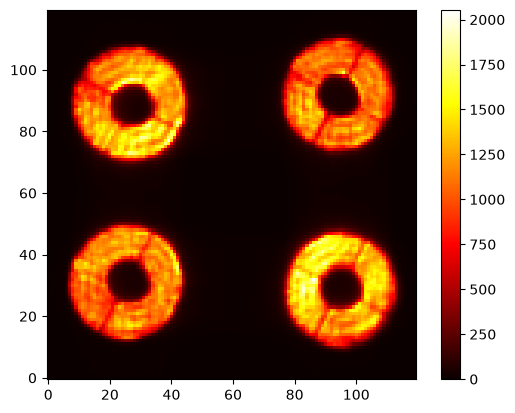

In [3]:
img = np.load('/raid1/mmenessini/calibration/EKARUS/data/OnSky_frame.npy')

ref_centers = get_frame_pupil_centers(img)
avg_center = np.mean(ref_centers,axis=0)
ref_dcenters = ref_centers-avg_center
print(ref_dcenters)

xmin = int(np.round(avg_center[0]))-60
xmax = int(np.round(avg_center[0]))+60
ymin = int(np.round(avg_center[1]))-60
ymax = int(np.round(avg_center[1]))+60

img = img[ymin:ymax,xmin:xmax]

plt.figure()
plt.imshow(img,origin='lower',cmap='hot')
plt.colorbar()

[[ 0.00380611 -0.25978917]
 [-0.3225274  -0.78038627]
 [-0.11793213 -0.91140454]
 [ 0.43665342  1.95157998]]


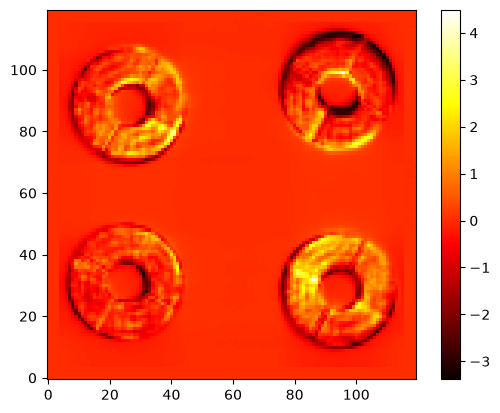

In [76]:
frame = fits.getdata('/raid1/mmenessini/results/EKARUS/frame.fits')[0]

centers = get_frame_pupil_centers(frame,xhalf=60,yhalf=60)
dcenters = centers-np.mean(centers,axis=0)
tilt_coeffs = ref_dcenters.T/30
print(dcenters-ref_dcenters)

plt.figure()
plt.imshow(frame,origin='lower',cmap='hot',vmax=200)
plt.imshow(img/np.mean(img)-frame/np.mean(frame),origin='lower',cmap='hot')
plt.colorbar()

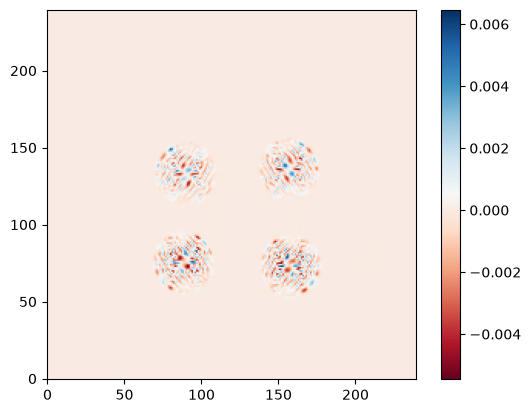

In [47]:
im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260802_233704.fits')
# im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260729_122235.fits')

plt.figure()
plt.imshow(im[:,290].reshape([240,240]),origin='lower',cmap='RdBu')
plt.colorbar()

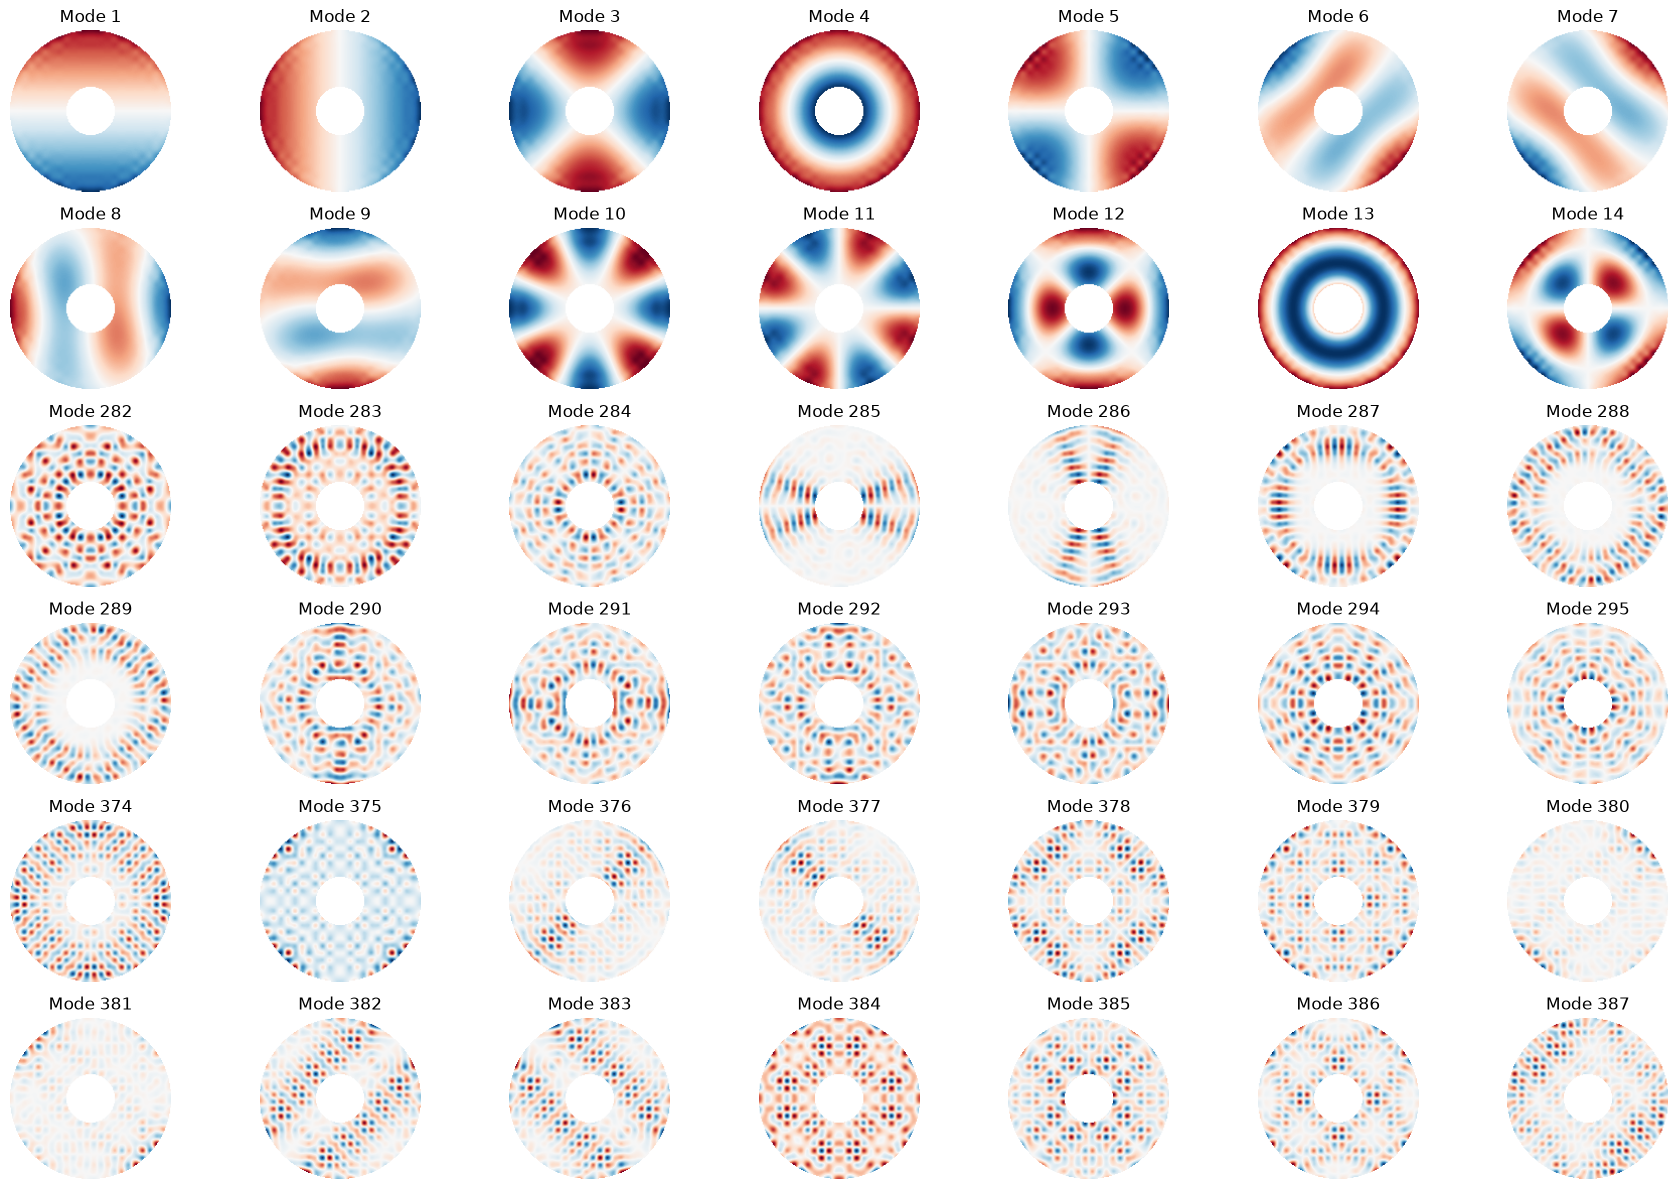

In [ ]:
m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_central_obstruction.npy')
iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/reordered_DM468_ifunc.fits')
pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/reordered_DM468_367pixels.fits')).astype(bool)
# m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_synthetic.npy')
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/simul_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/simul_DM468_160pixels.fits')).astype(bool)

kl_basis = (iffs @ m2c).T
max_modes = 42
mode_display = np.zeros((max_modes, pupil_mask.shape[0], pupil_mask.shape[1]))
idx_mask = np.where(pupil_mask)
mode_ids = np.zeros(max_modes,dtype=int)

for i in range(max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = i+1
    mode_img[idx_mask] = kl_basis[i]
    mode_display[i] = mode_img
for i in range(max_modes//3,2*max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]//1.5-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img
for i in range(2*max_modes//3,max_modes):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]//1.2-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img

# Plot the reshaped modes
n_rows = 6 #int(np.round(np.sqrt(max_modes)))
n_cols = 7 #int(np.ceil(max_modes / n_rows))
plt.figure(figsize=(18, 12))
for i in range(max_modes):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.ma.masked_array(mode_display[i],mask=1-pupil_mask),origin='lower',cmap='RdBu')
    plt.title(f'Mode {mode_ids[i]}')
    plt.axis('off')
plt.tight_layout()